In [8]:
import pandas as pd
import numpy as np


In [7]:
df_2009_2010 = pd.read_excel("dataset.xlsx", sheet_name="Year 2009-2010")
df_2010_2011 = pd.read_excel("dataset.xlsx", sheet_name="Year 2010-2011")
dataset = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)

STEP 1:
Preprocessing of Data


1.   Remove Missing CustomerID Rows

1.   Remove Cancellation from Invoice
2.   Remove Negitive or Zero Quantity


1.   Create TotalAmount = Price * Quantity







In [9]:
print(dataset.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [10]:
#change the Date
dataset["InvoiceDate"]=pd.to_datetime(dataset["InvoiceDate"])

#Remove Missing Customer ID
dataset = dataset.dropna(subset=["Customer ID"])

#Remove Cancellation from Invoice
dataset = dataset[~dataset["Invoice"].astype(str).str.contains("C")]

#Remove Negitive or Zero from quantity
dataset = dataset[dataset["Quantity"] > 0]

#Create TotalAmount
dataset["TotalAmount"] = dataset["Price"] * dataset["Quantity"]

The Basic Idea is:
Spilt the dataset into two windows, Past and Future and then extract feature from Past Window which will work as x for a machine learning Algorithm and y will be the True clv from future window,but we have to make sure one more thing that we have to include only those customers in Past window for which there is a Future CLv


In [11]:
#first find a cutoff date
cutoff_day=dataset["InvoiceDate"].max()-pd.DateOffset(months=2)

Now split the dataset into two window based on Cutoff date

In [12]:
Past = dataset[dataset["InvoiceDate"] < cutoff_day]
Future = dataset[dataset["InvoiceDate"] >= cutoff_day]

STEP2:
Now Extracting the following features from the Past window for only those customers which have a record in Future winodw


1.   Recency : Date of Last Time Purchase
2.   Frequency : Number of purchased a customer made


1.   Monetary: The total spending of a customer
2.   AverageGap = Average gap between purchases for each customer

1.   Tenure : The time the Customer had spend so far
2.   AverageOrderValue = Totalspending / Frequency

In [16]:
Recency = Past.groupby("Customer ID")["InvoiceDate"].max()
Recency = (cutoff_day-Recency).dt.days
Frequency = Past.groupby("Customer ID")["Invoice"].nunique()
Monetary = Past.groupby("Customer ID")["TotalAmount"].sum()
Tenure = Past.groupby("Customer ID")["InvoiceDate"].agg(lambda x: (x.max() - x.min()).days)
AverageOrderValue = Monetary / Frequency
AverageGap = Past.groupby("Customer ID")["InvoiceDate"].apply(avg_gap)

In [15]:
def avg_gap(x):
    # 1. Clean the data: remove nulls, sort, and get unique values
    x = x.dropna().unique()
    # DatetimeArray does not have a .sort() method, convert to Series to sort
    x = pd.Series(x).sort_values().values

    if len(x) <= 1:
        return 0

    # 2. Calculate gaps using the pandas Series constructor
    gaps = pd.Series(x).diff().dropna()

    # 3. Handle the result based on data type
    mean_gap = gaps.mean()

    # If the data is dates, return the number of days
    if hasattr(mean_gap, 'days'):
        return mean_gap.days

    # If the data is numbers, return the float/int
    return mean_gap

Function to calculate the Average Gap between Transactions for each customer

STEP3:
combining all the features to Make a new dataframe,
which will work as input(X) for ML Models.

In [17]:
features = pd.DataFrame({
    "Recency":Recency,
    "Frequency":Frequency,
    "Monetary":Monetary,
    "AverageGap":AverageGap,
    "Tenure":Tenure,
    "AverageOrderValue":AverageOrderValue
})

STEP4:
Now we will find the CLV value for each customer from the future window, which will work as Y for ML Models,there are two main points to take in consideration


1.   if a customer Id is in Past and also in the future value, Then based on Customer ID, X and Y will be merged
2.   if we have X (attributes) for a customer in past but we don't have CLV for that customer in future window then 0 will be assign to them.



In [18]:
Future = Future.dropna(subset=["Customer ID"])
Future["TotalAmount"] = Future["Price"] * Future["Quantity"]
CLV = Future.groupby("Customer ID")["TotalAmount"].sum()

STEP 5: Merge features and CLV based on Customer ID and customer exist in both assign and if not exist in future window then assign zero

In [19]:
data = features.merge(CLV, how="left", left_index=True, right_index=True)
data = data.fillna(0)

In [20]:
data

,Recency,Frequency,Monetary,AverageGap,Tenure,AverageOrderValue,TotalAmount
Customer ID,,,,,,,
12346.0,264,12,77556.46,36,400,6463.038333,0.00
12347.0,68,6,4114.18,54,274,685.696667,1519.14
12348.0,13,5,2019.40,90,362,403.880000,0.00
12349.0,346,3,2671.14,90,181,890.380000,1757.55
12350.0,248,1,334.40,0,0,334.400000,0.00
...,...,...,...,...,...,...,...
18283.0,34,16,1762.44,37,562,110.152500,974.21
18284.0,370,1,461.68,0,0,461.680000,0.00
18285.0,599,1,427.00,0,0,427.000000,0.00


STEP 6 : Train Test and Split

In [21]:
X = data.drop(columns=["TotalAmount"])
Y = np.log1p(data["TotalAmount"])

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

STEP 7:
train The Model


1.   Linear Regressor
2.   Random Forest Regressor


1.   XGBoost Regreesor





1:Linear Regressor

In [23]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
LGModel = LinearRegression()
LGModel.fit(X_train, Y_train)

LinearRegression()

2 : Random Forest Regressor

In [62]:
from sklearn.ensemble import RandomForestRegressor
RFModel = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
RFModel.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

3:XGBoost Regressor

In [72]:
from pandas._libs.lib import no_default
from xgboost import XGBRegressor
XGBModel = XGBRegressor(
    n_estimators=300,
    learning_rate=0.10,
    max_depth = 5,
    random_state = 42
)
XGBModel.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Now Evaluating the Models

In [73]:
Y_Predict_Regressor = LGModel.predict(X_test)
Y_Predict_RandomForest = RFModel.predict(X_test)
Y_Predict_XGBoost = XGBModel.predict(X_test)


Evaluation of The Models :

*   Criteria:


1.   Root Mean Squared Error
2.    Mean Absoulte Error


1.   R^2 Score







In [74]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#Metrics for Regression Model
mse_regressor = mean_squared_error(np.expm1(Y_test), np.expm1(Y_Predict_Regressor))
mae_regressor = mean_absolute_error(np.expm1(Y_test), np.expm1(Y_Predict_Regressor))
r2_regressor = r2_score(np.expm1(Y_test), np.expm1(Y_Predict_Regressor))

#for Random Forest Regressor
mse_randomforest = mean_squared_error(np.expm1(Y_test), np.expm1(Y_Predict_RandomForest))
mae_randomforest = mean_absolute_error(np.expm1(Y_test), np.expm1(Y_Predict_RandomForest))
r2_randomforest = r2_score(np.expm1(Y_test), np.expm1(Y_Predict_RandomForest))

#for XGBoost
mse_xgboost = mean_squared_error(np.expm1(Y_test),np.expm1(Y_Predict_XGBoost))
mae_xgboost = mean_absolute_error(np.expm1(Y_test),np.expm1(Y_Predict_XGBoost))
r2_xgboost = r2_score(np.expm1(Y_test),np.expm1(Y_Predict_XGBoost))

print(f"Linear Regressor\n")
print(f"Mean Squared Error :{mse_regressor}\n")
print(f"Mean Absolute Error :{mae_regressor}\n")
print(f"R^2 Score :{r2_regressor}\n")

print(f"Random Forest Regressor\n")
print(f"Mean Squared Error{mse_randomforest}\n")
print(f"Mean Absolute Error :{mae_randomforest}\n")
print(f"R^2 Score :{r2_randomforest}\n")

print(f"XG Boost\n")
print(f"Mean Squared Error{mse_xgboost}\n")
print(f"Mean Absolute Error :{mae_xgboost}\n")
print(f"R^2 Score :{r2_xgboost}\n")

Linear Regressor

Mean Squared Error :108954444597973.44

Mean Absolute Error :315666.8599539621

R^2 Score :-3422660.7596390764

Random Forest Regressor

Mean Squared Error30104376.945101526

Mean Absolute Error :529.998342666725

R^2 Score :0.05431026565321295

XG Boost

Mean Squared Error29413271.31132371

Mean Absolute Error :516.1041933679223

R^2 Score :0.07602044767773264



Visualizing the Results

In [56]:
result = pd.DataFrame(index=X_test.index)
result["Predicted_CLV"] = np.expm1(Y_Predict_XGBoost)
result["Segments"] = pd.qcut(result["Predicted_CLV"], q=4, labels=['Low','Mid','High','VIP'])
result.head()

,Predicted_CLV,Segments
Customer ID,,
16384.0,6.882889,High
13648.0,4.499455,Mid
17190.0,11.962488,High
17819.0,123.209068,VIP
14355.0,3.107756,Mid


visualizing using seaborn

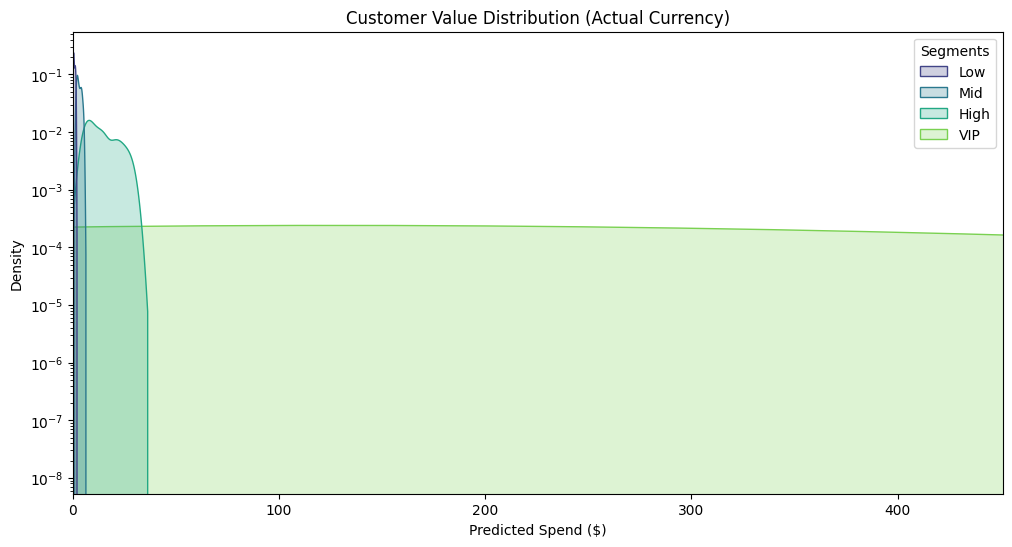

In [61]:
# Assuming you did something like this:


plt.figure(figsize=(12, 6))
sns.kdeplot(data=result, x='Predicted_CLV', hue='Segments', fill=True, palette='viridis')
plt.yscale('log')
# This zooms in on the main bulk of customers, while still showing the 'tail'
plt.xlim(0, result['Predicted_CLV'].quantile(0.95))
plt.title('Customer Value Distribution (Actual Currency)')
plt.xlabel('Predicted Spend ($)')
plt.show()

In [58]:
# 1. Group by Segment and sum the real dollar predictions
segment_totals = result.groupby('Segments')['Predicted_CLV'].sum().reset_index()

# 2. Rename columns for clarity
segment_totals.columns = ['Segments', 'Total_Predicted_Value']

# 3. Sort by value to see the impact
segment_totals = segment_totals.sort_values(by='Total_Predicted_Value', ascending=False)

print(segment_totals)

  Segments  Total_Predicted_Value
3      VIP          123493.781250
2     High            3878.652344
1      Mid             858.470032
0      Low             211.374222


/tmp/ipykernel_356/191604367.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_totals = result.groupby('Segments')['Predicted_CLV'].sum().reset_index()


Visualizing the Economic Impact

/tmp/ipykernel_356/1702872678.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segments', y='Total_Predicted_Value', data=segment_totals, palette='viridis')


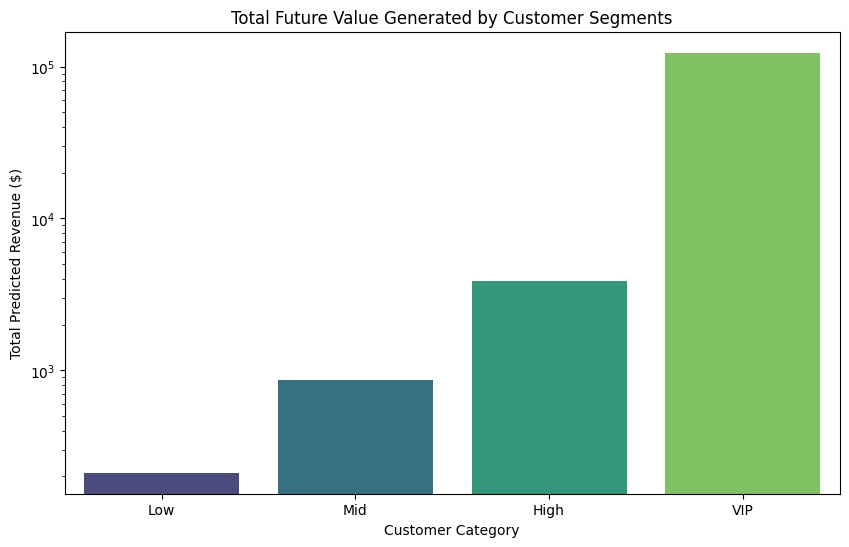

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x='Segments', y='Total_Predicted_Value', data=segment_totals, palette='viridis')
plt.yscale('log')
# Format the y-axis to look like currency
plt.title('Total Future Value Generated by Customer Segments')
plt.ylabel('Total Predicted Revenue ($)')
plt.xlabel('Customer Category')
plt.show()